In [23]:
import dynamiqs as dq
import matplotlib.pyplot as plt
import jax.numpy as jnp

In [24]:
na = 20  # Hilbert space dimensions


g2 = 1.0  # Two-photon coupling strength
eps_d = -4  # Drive amplitude
eps_z = 1 # z-gate strengh

alpha = jnp.sqrt((-1*eps_d)/g2)
kappa_b = 1  # Decay rate

kappa_2 = 4 * (g2**2) / kappa_b  # Two-photon loss rate

period = jnp.pi/(4*alpha*eps_z)  
T = 10*period # Total simulation time

In [25]:
a = dq.destroy(na)
dag_a = dq.dag(a)
H_z = eps_z*(dag_a + a)
H = H_z

exp_ops = [dq.dag(a) @ a]

In [30]:
loss_op = jnp.sqrt(kappa_2) * (a @ a - alpha * alpha * dq.eye(na))

In [31]:
psi0 = dq.fock((na), (0))  # Initial state

In [32]:
t_save = jnp.linspace(0, T, 100)
res = dq.mesolve(H, [loss_op], psi0, t_save, exp_ops=exp_ops)

|██████████| 100.0% ◆ elapsed 282.11ms ◆ remaining 0.00ms  


100%|██████████| 50/50 [00:03<00:00, 12.56it/s]


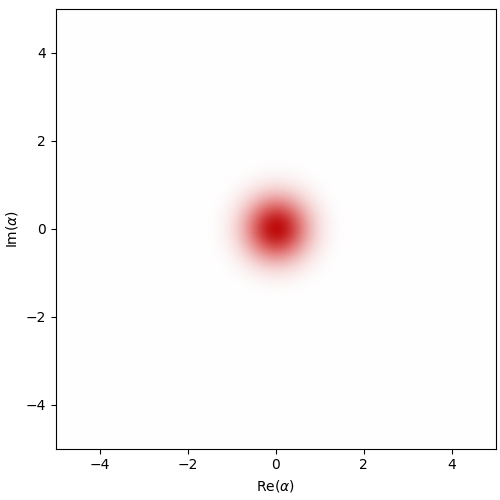

In [33]:
rho_a = dq.ptrace(res.states, 0)
# Then plot Wigner gif of rho_a
dq.plot.wigner_gif(rho_a)

|▏         |   1.4% ◆ elapsed 3.13ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 284.07ms ◆ remaining 0.00ms  

100%|██████████| 50/50 [00:04<00:00, 11.42it/s]


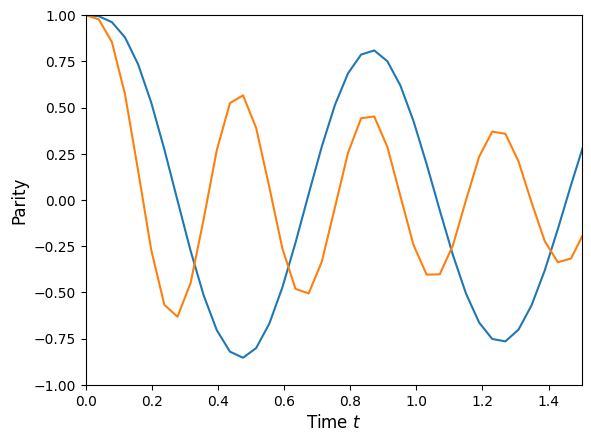

In [40]:

eps_z2 = 2 # z-gate strengh

period2 = jnp.pi/(4*alpha*eps_z2)  
T2 = 10*period # Total simulation time

a = dq.destroy(na)
dag_a = dq.dag(a)
H_z2 = eps_z2*(dag_a + a)
H2 = H_z2

res2 = dq.mesolve(H2, [loss_op], psi0, t_save, exp_ops=exp_ops)

rho_a2 = dq.ptrace(res2.states, 0)
# Then plot Wigner gif of rho_a
dq.plot.wigner_gif(rho_a2)

plt.plot(t_save, dq.expect(dq.parity(na), rho_a).real)

plt.plot(t_save, dq.expect(dq.parity(na), rho_a2).real)

plt.xlabel(r"Time $t$", fontsize=12)
plt.ylabel(r"Parity", fontsize=12)
plt.ylim(-1, 1.0)
plt.xlim(0,1.5)

plt.show()

In [53]:
na, nb = 20,5  # Hilbert space dimensions

a, b = dq.destroy(na, nb)
dag_a, dag_b = dq.dag(a), dq.dag(b)
H_2ph = g2 * dag_a @ dag_a @ b + jnp.conj(g2) * a @ a @ dag_b
H_d = jnp.conj(eps_d) * b + eps_d * dag_b
H = H_2ph + H_d


g2 = 1.0  # Two-photon coupling strength
eps_d = -4  # Drive amplitude
eps_z = 1 # z-gate strengh

alpha = jnp.sqrt((-1*eps_d)/g2)
kappa_b = 1  # Decay rate

kappa_2 = 4 * (g2**2) / kappa_b  # Two-photon loss rate

T_z = jnp.pi/(4*alpha*eps_z)  
T = 10*T_z # Total simulation time

In [54]:
a, b = dq.destroy(na, nb)
dag_a, dag_b = dq.dag(a), dq.dag(b)
H_2ph = g2 * dag_a @ dag_a @ b + jnp.conj(g2) * a @ a @ dag_b
H_d = jnp.conj(eps_d) * b + eps_d * dag_b
H_z = eps_z*(dag_a + a)
H = H_2ph + H_d + H_z

exp_ops = [dq.dag(a) @ a]

In [55]:
loss_op = jnp.sqrt(kappa_2) * (a @ a - alpha_squared * dq.eye(na,nb))

In [56]:
psi0 = dq.fock((na,nb), (0,0))  # Initial state

In [57]:
t_save = jnp.linspace(0, T, 100)
res = dq.mesolve(H, [loss_op], psi0, t_save, exp_ops=exp_ops)

|█████     |  50.9% ◆ elapsed 3.20s ◆ remaining 3.16s   


|██████████| 100.0% ◆ elapsed 6.44s ◆ remaining 0.00ms  

100%|██████████| 50/50 [00:07<00:00,  6.89it/s]


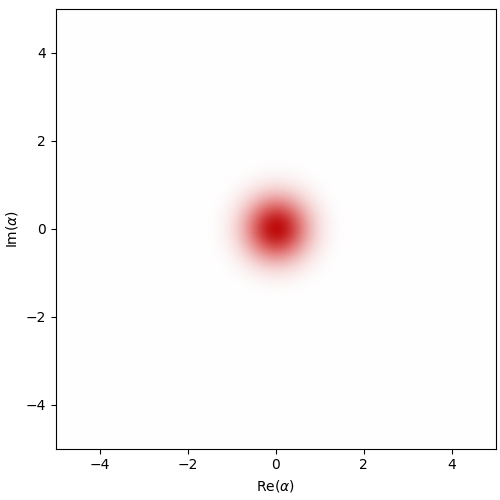

In [58]:
rho_a = dq.ptrace(res.states, 0)
# Then plot Wigner gif of rho_a
dq.plot.wigner_gif(rho_a)

(0.0, 1.5)

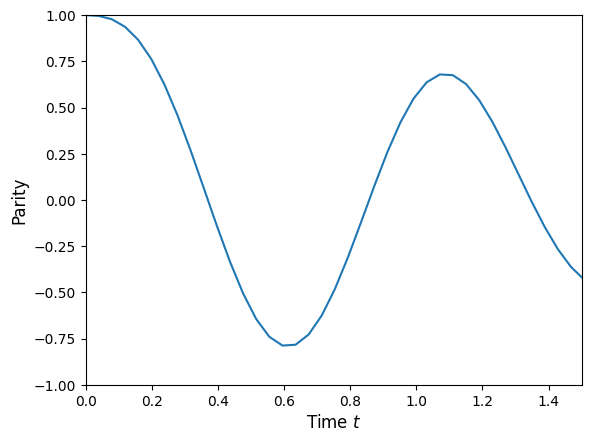

In [52]:
plt.plot(t_save, dq.expect(dq.parity(na), rho_a).real)
plt.xlabel(r"Time $t$", fontsize=12)
plt.ylabel(r"Parity", fontsize=12)
plt.ylim(-1, 1.0)
plt.xlim(0,1.5)